In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from shapely.geometry import Point
import pickle

In [13]:
sites_df = pd.read_csv('../01_cleaned_data/sites_df.csv')

with open('../01_cleaned_data/site_grids/site_polygons.pkl', 'rb') as f:
    site_polygons_stereo = pickle.load(f)

px_size_slope    = 40
landing_spot_m   = 100
landing_spot_px  = landing_spot_m // px_size_slope
ez_radius_m      = 2000
ez_radius_px     = ez_radius_m // px_size_slope
psr_traverse_deg = 10.0

SLOPE_THRESHOLD = 25.0
ILLUM_THRESHOLD = 33.0
DTE_THRESHOLD   = 50.0

site_polygons_buffered = {}
for site, poly in site_polygons_stereo.items():
    buffered = poly.buffer(-ez_radius_m)
    site_polygons_buffered[site] = buffered
    status = "valid area remains" if not buffered.is_empty else "TOO SMALL"
    area_remaining = buffered.area / 1_000_000 if not buffered.is_empty else 0
    print(f"{site:25s}  buffered area: {area_remaining:7.2f} km²  ({status})")

ky, kx      = np.ogrid[-ez_radius_px : ez_radius_px + 1,
                        -ez_radius_px : ez_radius_px + 1]
ez_kernel   = (kx**2 + ky**2 <= ez_radius_px**2).astype(float)
n_ez_pixels = ez_kernel.sum()
px_area_km2 = (px_size_slope ** 2) / 1_000_000

spot_half   = max(1, landing_spot_px // 2)
spot_kernel = np.ones((2*spot_half+1, 2*spot_half+1))
n_spot_px   = spot_kernel.sum()

print(f"\nEZ area at 40m/px:     {n_ez_pixels * px_area_km2:.2f} km²")
print(f"Landing spot kernel:   {spot_kernel.shape} px")

Nobile Rim 2               buffered area:  256.00 km²  (valid area remains)
Mons Mouton                buffered area:  144.00 km²  (valid area remains)
Malapert Massif            buffered area:  289.00 km²  (valid area remains)
de Gerlache Rim 2          buffered area:  256.00 km²  (valid area remains)
Mons Mouton Plateau        buffered area: 3928.67 km²  (valid area remains)
Slater Plain               buffered area:  255.84 km²  (valid area remains)
Peak near Cabeus B         buffered area:  255.84 km²  (valid area remains)
Nobile Rim 1               buffered area:  256.00 km²  (valid area remains)
Haworth                    buffered area:  665.64 km²  (valid area remains)

EZ area at 40m/px:     12.55 km²
Landing spot kernel:   (3, 3) px


In [ ]:
def critic_weights(data):
    """
    CRITIC -- Criteria Importance Through Intercriteria Correlation
    Diakoulaki et al. (1995), Computers & Operations Research
    doi:10.1016/0305-0548(94)00059-H
    """
    col_min  = data.min(axis=0)
    col_max  = data.max(axis=0)
    norm     = (data - col_min) / (col_max - col_min + 1e-12)
    std_j    = norm.std(axis=0, ddof=1)
    corr     = np.corrcoef(norm.T)
    conflict = (1 - corr).sum(axis=1)
    C        = std_j * conflict
    return C / C.sum()


def topsis_scores(matrix, weights, directions):
    """
    TOPSIS -- Technique for Order Preference by Similarity to Ideal Solution
    Hwang & Yoon (1981), following Peña-Asensio et al. (Acta Astronautica, 2024)
    doi:10.1016/j.actaastro.2024.10.049
    """
    norm     = matrix / (np.sqrt((matrix**2).sum(axis=0)) + 1e-12)
    weighted = norm * weights
    dirs     = np.array(directions)
    best     = np.where(dirs == '+', weighted.max(axis=0), weighted.min(axis=0))
    worst    = np.where(dirs == '+', weighted.min(axis=0), weighted.max(axis=0))
    d_best   = np.sqrt(((weighted - best)  ** 2).sum(axis=1))
    d_worst  = np.sqrt(((weighted - worst) ** 2).sum(axis=1))
    return d_worst / (d_best + d_worst + 1e-12)


def find_optimal_psr(psr_x_all, psr_y_all, h2_ppm_grid, h2_transform,
                     slope_arr, slope_transform,
                     ez_x, ez_y, ez_radius_m, spot_radius_m,
                     psr_traverse_deg=10.0):
    """
    Among all official PSR pixels (Mazarico et al. 2011) within the EZ,
    excluding the landing spot, identify the pixel with the best combined
    score of accessibility (minimizing distance) and hydrogen abundance
    (maximizing ppm), using a two-criterion TOPSIS ranking. Only PSR
    pixels reachable via traverse slope <=10deg are considered eligible.
    ref: Mazarico et al. (2011), Icarus, doi:10.1016/j.icarus.2010.10.030
         Wueller et al. (2026), JGR Planets, doi:10.1029/2025JE009434
         Peña-Asensio et al. (2023), Acta Astronautica,
         doi:10.1016/j.actaastro.2023.10.010
    """
    if len(psr_x_all) == 0:
        return {'has_psr': False, 'psr_dist_km': np.nan,
                'psr_traverse_ok': False, 'h2_at_psr': np.nan}

    dist_all    = np.sqrt((psr_x_all - ez_x)**2 + (psr_y_all - ez_y)**2)
    within_mask = (dist_all <= ez_radius_m) & (dist_all > spot_radius_m)

    if not within_mask.any():
        return {'has_psr': False, 'psr_dist_km': np.nan,
                'psr_traverse_ok': False, 'h2_at_psr': np.nan}

    cand_x    = psr_x_all[within_mask]
    cand_y    = psr_y_all[within_mask]
    cand_dist = dist_all[within_mask]

    # sample hydrogen abundance at each candidate PSR pixel
    cand_cols = np.clip(((cand_x - h2_transform.c) / h2_transform.a).astype(int),
                        0, h2_ppm_grid.shape[1]-1)
    cand_rows = np.clip(((cand_y - h2_transform.f) / h2_transform.e).astype(int),
                        0, h2_ppm_grid.shape[0]-1)
    cand_h2   = h2_ppm_grid[cand_rows, cand_cols]

    # only keep candidates with valid hydrogen data
    valid = ~np.isnan(cand_h2)
    if not valid.any():
        # fall back to nearest PSR if none have hydrogen coverage
        nearest_idx = np.argmin(cand_dist)
        chosen_x, chosen_y, chosen_dist = cand_x[nearest_idx], cand_y[nearest_idx], cand_dist[nearest_idx]
        chosen_h2 = np.nan
    else:
        cand_x, cand_y, cand_dist, cand_h2 = \
            cand_x[valid], cand_y[valid], cand_dist[valid], cand_h2[valid]

        # two-criterion TOPSIS: distance (minimize), hydrogen (maximize)
        M = np.column_stack([cand_dist, cand_h2])
        norm     = M / (np.sqrt((M**2).sum(axis=0)) + 1e-12)
        weighted = norm * np.array([0.5, 0.5])
        best     = np.array([weighted[:, 0].min(), weighted[:, 1].max()])
        worst    = np.array([weighted[:, 0].max(), weighted[:, 1].min()])
        d_best   = np.sqrt(((weighted - best)  ** 2).sum(axis=1))
        d_worst  = np.sqrt(((weighted - worst) ** 2).sum(axis=1))
        psr_score = d_worst / (d_best + d_worst + 1e-12)

        best_idx = np.argmax(psr_score)
        chosen_x, chosen_y, chosen_dist, chosen_h2 = \
            cand_x[best_idx], cand_y[best_idx], cand_dist[best_idx], cand_h2[best_idx]

    psr_dist_km = round(chosen_dist / 1000, 3)

    # verify traverse feasibility to the chosen PSR
    n_steps = max(2, int(chosen_dist / slope_transform.a))
    line_x  = np.linspace(ez_x, chosen_x, n_steps)
    line_y  = np.linspace(ez_y, chosen_y, n_steps)

    line_col = np.clip(((line_x - slope_transform.c) / slope_transform.a).astype(int),
                       0, slope_arr.shape[1]-1)
    line_row = np.clip(((line_y - slope_transform.f) / slope_transform.e).astype(int),
                       0, slope_arr.shape[0]-1)

    traverse_slope = slope_arr[line_row, line_col]
    traverse_ok    = float(np.nanmedian(traverse_slope)) <= psr_traverse_deg

    return {
        'has_psr': True,
        'psr_dist_km': psr_dist_km,
        'psr_traverse_ok': traverse_ok,
        'h2_at_psr': round(float(chosen_h2), 2) if not np.isnan(chosen_h2) else np.nan,
    }

In [ ]:
# EZ selection using a landing-spot-centered search across each region.
# for every 100x100m landing spot fully compliant with slope <=5deg and
# fully contained within the buffered site boundary, all five criteria
# are evaluated. candidates satisfying all five are ranked by CRITIC-TOPSIS
# using illumination, DTE, slope, and elevation variability; the top-ranked
# fully-compliant candidate is selected as the site's optimal EZ. if no
# candidate satisfies all five criteria, the highest-scoring candidate
# overall is selected and unmet criteria are explicitly flagged.
#
# ref: Gracy & Lee (LPSC 2024) https://www.hou.usra.edu/meetings/lpsc2024/pdf/1695.pdf
#      Wueller et al. (2026) doi:10.1029/2025JE009434

criteria_directions = ['+', '+', '+', '-']

site_results = []

for _, row in sites_df.iterrows():
    site_key  = row['site_key']
    grid_file = f'../01_cleaned_data/site_grids/{site_key}_grids.pkl'

    with open(grid_file, 'rb') as f:
        g = pickle.load(f)

    slope_arr   = g['slope']
    elev_arr    = g['elev']
    illum_pct   = g['illum_pct']
    dte_pct     = g['dte_pct']
    lpsr_grid   = g['lpsr_grid']
    h2_ppm_grid = g['h2_ppm_grid']
    search_ws   = g['search_ws']
    buf         = ez_radius_px

    buffered_poly = site_polygons_buffered[row['Site']]

    valid_slope     = (~np.isnan(slope_arr) & (slope_arr <= 5)).astype(float)
    spot_safe_count = fftconvolve(valid_slope, spot_kernel, mode='same')
    spot_fully_safe = (spot_safe_count >= n_spot_px - 0.5)

    spot_candidates_mask = np.zeros_like(spot_fully_safe)
    spot_candidates_mask[buf:-buf, buf:-buf] = spot_fully_safe[buf:-buf, buf:-buf]

    cand_ys, cand_xs = np.where(spot_candidates_mask)

    filtered_ys, filtered_xs = [], []
    for gy, gx in zip(cand_ys, cand_xs):
        x_stereo = g['transform'].c + gx * g['transform'].a
        y_stereo = g['transform'].f + gy * g['transform'].e
        if buffered_poly.contains(Point(x_stereo, y_stereo)):
            filtered_ys.append(gy)
            filtered_xs.append(gx)

    cand_ys = np.array(filtered_ys)
    cand_xs = np.array(filtered_xs)

    print(f"\n{row['Site']}")
    print(f"  Landing spots within EZ-buffered boundary: {len(cand_ys):>5}")

    if len(cand_ys) == 0:
        site_results.append({'Site': row['Site'], 'valid': False,
                             'note': 'no landing spot with full EZ inside site boundary'})
        continue

    safe_binary    = np.where(np.isnan(slope_arr), 0.0,
                              (slope_arr <= 5).astype(float))
    safe_count_map = fftconvolve(safe_binary, ez_kernel, mode='same')
    pct_safe_map   = (safe_count_map / n_ez_pixels) * 100

    # precompute real-world coordinates of all PSR pixels once per site
    H_lpsr, W_lpsr = lpsr_grid.shape
    rows_lpsr, cols_lpsr = np.indices((H_lpsr, W_lpsr))
    x_grid_lpsr = g['lpsr_transform'].c + cols_lpsr * g['lpsr_transform'].a
    y_grid_lpsr = g['lpsr_transform'].f + rows_lpsr * g['lpsr_transform'].e

    psr_mask_all = lpsr_grid >= 0.5
    psr_ys_all, psr_xs_all = np.where(psr_mask_all)
    psr_x_all = x_grid_lpsr[psr_ys_all, psr_xs_all]
    psr_y_all = y_grid_lpsr[psr_ys_all, psr_xs_all]

    print(f"  Total PSR pixels in search area: {len(psr_x_all)}")

    candidates = []

    for gy, gx in zip(cand_ys, cand_xs):
        pct_safe = pct_safe_map[gy, gx]
        if np.isnan(pct_safe):
            continue

        ey0 = max(0, gy - ez_radius_px); ey1 = min(elev_arr.shape[0], gy + ez_radius_px + 1)
        ex0 = max(0, gx - ez_radius_px); ex1 = min(elev_arr.shape[1], gx + ez_radius_px + 1)
        e_patch = elev_arr[ey0:ey1, ex0:ex1]
        hp, wp  = e_patch.shape
        Yp, Xp  = np.ogrid[:hp, :wp]
        m_patch = (Xp-(gx-ex0))**2 + (Yp-(gy-ey0))**2 <= ez_radius_px**2
        e_vals  = e_patch[m_patch & ~np.isnan(e_patch)]
        if len(e_vals) == 0:
            continue
        elev_std  = float(np.nanstd(e_vals))
        elev_mean = float(np.nanmean(e_vals))

        ez_x = g['transform'].c + gx * g['transform'].a
        ez_y = g['transform'].f + gy * g['transform'].e

        illum_col = int((ez_x - g['illum_transform'].c) / g['illum_transform'].a)
        illum_row = int((ez_y - g['illum_transform'].f) / g['illum_transform'].e)
        ez_r_i    = ez_radius_m / abs(g['illum_transform'].a)

        iy0 = max(0, int(illum_row - ez_r_i)); iy1 = min(illum_pct.shape[0], int(illum_row + ez_r_i) + 1)
        ix0 = max(0, int(illum_col - ez_r_i)); ix1 = min(illum_pct.shape[1], int(illum_col + ez_r_i) + 1)
        if iy1 <= iy0 or ix1 <= ix0:
            continue
        i_patch = illum_pct[iy0:iy1, ix0:ix1]
        hi, wi  = i_patch.shape
        Yi, Xi  = np.ogrid[:hi, :wi]
        m_i     = (Xi-(illum_col-ix0))**2 + (Yi-(illum_row-iy0))**2 <= ez_r_i**2
        i_vals  = i_patch[m_i & ~np.isnan(i_patch)]
        if len(i_vals) == 0:
            continue
        illum_max  = float(np.nanmax(i_vals))
        illum_mean = float(np.nanmean(i_vals))

        dte_col = int((ez_x - g['dte_transform'].c) / g['dte_transform'].a)
        dte_row = int((ez_y - g['dte_transform'].f) / g['dte_transform'].e)
        ez_r_d  = ez_radius_m / abs(g['dte_transform'].a)

        dy0 = max(0, int(dte_row - ez_r_d)); dy1 = min(dte_pct.shape[0], int(dte_row + ez_r_d) + 1)
        dx0 = max(0, int(dte_col - ez_r_d)); dx1 = min(dte_pct.shape[1], int(dte_col + ez_r_d) + 1)
        if dy1 <= dy0 or dx1 <= dx0:
            continue
        d_patch = dte_pct[dy0:dy1, dx0:dx1]
        hd, wd  = d_patch.shape
        Yd, Xd  = np.ogrid[:hd, :wd]
        m_d     = (Xd-(dte_col-dx0))**2 + (Yd-(dte_row-dy0))**2 <= ez_r_d**2
        d_vals  = d_patch[m_d & ~np.isnan(d_patch)]
        if len(d_vals) == 0:
            continue
        dte_max  = float(np.nanmax(d_vals))
        dte_mean = float(np.nanmean(d_vals))

        h2_patch = h2_ppm_grid[ey0:ey1, ex0:ex1]
        h2_vals  = h2_patch[m_patch & ~np.isnan(h2_patch)]
        h2_max   = float(np.nanmax(h2_vals))  if len(h2_vals) > 0 else np.nan
        h2_mean  = float(np.nanmean(h2_vals)) if len(h2_vals) > 0 else np.nan

        psr_result = find_optimal_psr(
            psr_x_all, psr_y_all, h2_ppm_grid, g['transform'],
            slope_arr, g['transform'],
            ez_x, ez_y, ez_radius_m, landing_spot_m / 2,
            psr_traverse_deg=psr_traverse_deg
        )

        candidates.append({
            'gy': gy, 'gx': gx, 'ez_x': ez_x, 'ez_y': ez_y,
            'pct_safe': pct_safe, 'elev_mean': elev_mean, 'elev_std': elev_std,
            'illum_max': illum_max, 'illum_mean': illum_mean,
            'dte_max': dte_max, 'dte_mean': dte_mean,
            'h2_ez_max': h2_max, 'h2_ez_mean': h2_mean,
            'h2_at_psr': psr_result['h2_at_psr'],
            'has_psr': psr_result['has_psr'],
            'psr_dist_km': psr_result['psr_dist_km'],
            'psr_traverse_ok': psr_result['psr_traverse_ok'],
        })

    if len(candidates) == 0:
        site_results.append({'Site': row['Site'], 'valid': False,
                             'note': 'no candidates with complete data coverage'})
        continue

    cand_df = pd.DataFrame(candidates)

    cand_df['meets_slope'] = cand_df['pct_safe']  >= SLOPE_THRESHOLD
    cand_df['meets_illum'] = cand_df['illum_max'] >= ILLUM_THRESHOLD
    cand_df['meets_dte']   = cand_df['dte_max']   >= DTE_THRESHOLD
    cand_df['meets_psr']   = cand_df['has_psr'] & cand_df['psr_traverse_ok']
    cand_df['meets_all']   = (cand_df['meets_slope'] & cand_df['meets_illum'] &
                              cand_df['meets_dte']   & cand_df['meets_psr'])

    n_meets_all = int(cand_df['meets_all'].sum())
    print(f"  Candidates meeting all 5 criteria: {n_meets_all} / {len(cand_df)}")

    metric_cols = ['illum_max', 'dte_max', 'pct_safe', 'elev_std']
    M = cand_df[metric_cols].values.astype(float)
    w = critic_weights(M)
    cand_df['ez_score'] = topsis_scores(M, w, criteria_directions)

    fully_qualified = cand_df[cand_df['meets_all']].sort_values(
        'ez_score', ascending=False
    )

    if len(fully_qualified) > 0:
        chosen = fully_qualified.iloc[0]
    else:
        chosen = cand_df.sort_values('ez_score', ascending=False).iloc[0]

    dy_km     = (int(chosen['gy']) - buf - search_ws) * px_size_slope / 1000
    dx_km     = (int(chosen['gx']) - buf - search_ws) * px_size_slope / 1000
    offset_km = round(np.sqrt(dy_km**2 + dx_km**2), 2)

    unmet = []
    if chosen['pct_safe']  < SLOPE_THRESHOLD: unmet.append('Slope')
    if chosen['illum_max'] < ILLUM_THRESHOLD: unmet.append('Illumination')
    if chosen['dte_max']   < DTE_THRESHOLD:   unmet.append('DTE')
    if not (chosen['has_psr'] and chosen['psr_traverse_ok']): unmet.append('PSR_access')

    site_results.append({
        'Site':                row['Site'],
        'Lat':                 row['Lat'],
        'Lon':                 row['Lon'],
        'Area_km2':            row['Area_km2'],
        'EZ_X_stereo':         round(chosen['ez_x'], 2),
        'EZ_Y_stereo':         round(chosen['ez_y'], 2),
        'Landing_spot_flat':   True,
        'Pct_area_HLS_safe':   round(chosen['pct_safe'],  1),
        'Elevation_mean_m':    round(chosen['elev_mean'], 1),
        'Elevation_std_m':     round(chosen['elev_std'],  1),
        'Illumination_max':    round(chosen['illum_max'],  1),
        'Illumination_mean':   round(chosen['illum_mean'], 1),
        'DTE_max':             round(chosen['dte_max'],  1),
        'DTE_mean':            round(chosen['dte_mean'], 1),
        'H2_max_ppm':          round(chosen['h2_at_psr'], 2) if not pd.isna(chosen['h2_at_psr']) else np.nan,
        'H2_ez_max_ppm':       round(chosen['h2_ez_max'], 2) if not pd.isna(chosen['h2_ez_max']) else np.nan,
        'H2_ez_mean_ppm':      round(chosen['h2_ez_mean'], 2) if not pd.isna(chosen['h2_ez_mean']) else np.nan,
        'EZ_score':            round(float(chosen['ez_score']), 4),
        'EZ_offset_km':        offset_km,
        'Has_PSR_access':      bool(chosen['has_psr']),
        'PSR_dist_km':         chosen['psr_dist_km'],
        'PSR_traverse_ok':     bool(chosen['psr_traverse_ok']),
        'Meets_all_criteria':  (len(unmet) == 0),
        'Unmet_criteria':      ', '.join(unmet) if unmet else 'None',
        'n_candidates':        len(cand_df),
        'n_meets_all':         n_meets_all,
        'valid':               True,
    })

    print(f"  Selected EZ -- unmet criteria: {', '.join(unmet) if unmet else 'None'}")

lola_all = pd.DataFrame(site_results)


Nobile Rim 2
  Landing spots within EZ-buffered boundary: 14541
  Total PSR pixels in search area: 191744
  Candidates meeting all 5 criteria: 10156 / 14541
  Selected EZ -- unmet criteria: None

Mons Mouton
  Landing spots within EZ-buffered boundary:  3530
  Total PSR pixels in search area: 29040
  Candidates meeting all 5 criteria: 175 / 3530
  Selected EZ -- unmet criteria: None

Malapert Massif
  Landing spots within EZ-buffered boundary:  2729
  Total PSR pixels in search area: 18857
  Candidates meeting all 5 criteria: 300 / 2729
  Selected EZ -- unmet criteria: None

de Gerlache Rim 2
  Landing spots within EZ-buffered boundary: 11790
  Total PSR pixels in search area: 36069
  Candidates meeting all 5 criteria: 8256 / 11790
  Selected EZ -- unmet criteria: None

Mons Mouton Plateau
  Landing spots within EZ-buffered boundary: 241624
  Total PSR pixels in search area: 405689
  Candidates meeting all 5 criteria: 175200 / 241624
  Selected EZ -- unmet criteria: None

Slater Plain

In [16]:
print(lola_all[['Site', 'Meets_all_criteria', 'Unmet_criteria',
                 'Pct_area_HLS_safe', 'Illumination_max', 'DTE_max',
                 'Has_PSR_access', 'PSR_dist_km', 'PSR_traverse_ok',
                 'H2_max_ppm', 'EZ_score']]
      .sort_values(['Meets_all_criteria', 'EZ_score'], ascending=[False, False])
      .to_string(index=False))

               Site  Meets_all_criteria Unmet_criteria  Pct_area_HLS_safe  Illumination_max  DTE_max  Has_PSR_access  PSR_dist_km  PSR_traverse_ok  H2_max_ppm  EZ_score
    Malapert Massif                True           None               30.4              89.9    100.0            True        0.161             True      141.65    0.9736
       Nobile Rim 2                True           None               56.4              52.1     81.0            True        0.721             True      105.51    0.9673
Mons Mouton Plateau                True           None               82.0              52.0     99.5            True        0.708             True      107.84    0.9320
            Haworth                True           None               84.1              52.4     65.2            True        0.122             True      132.27    0.8594
       Nobile Rim 1                True           None               42.4              73.7     98.5            True        0.591             True      151

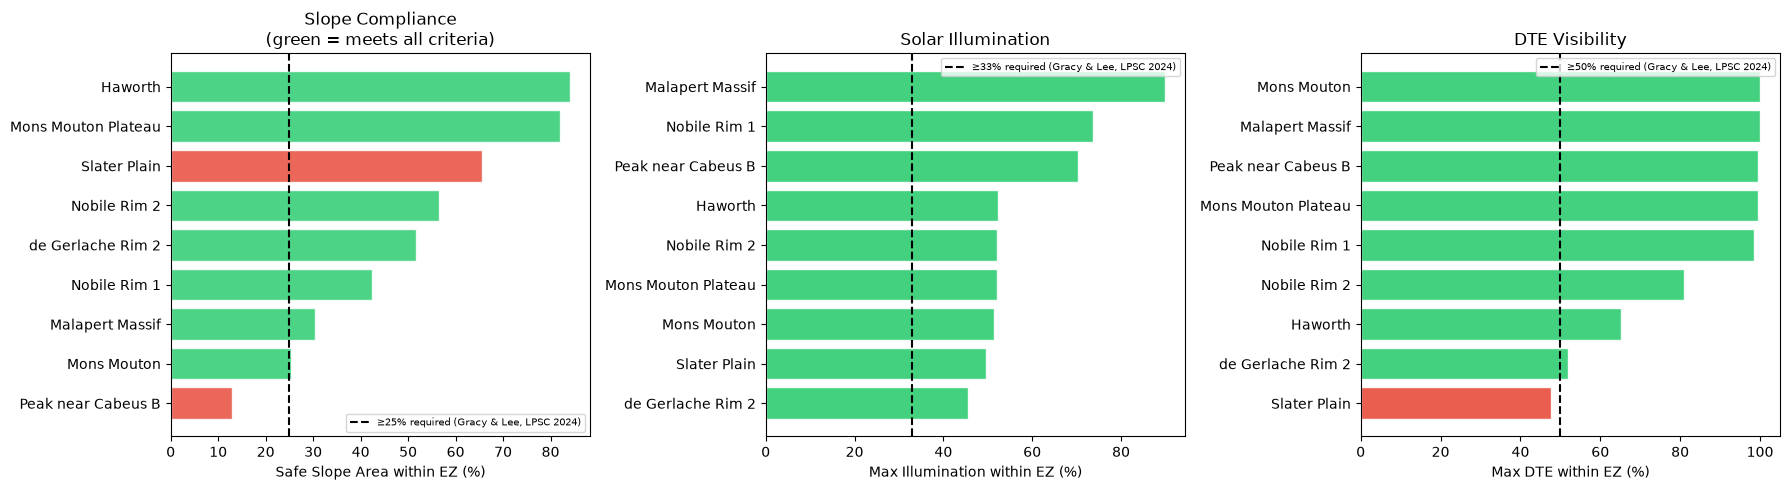

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sp = lola_all.sort_values('Pct_area_HLS_safe')
colors_status = ['#2ecc71' if m else '#e74c3c' for m in sp['Meets_all_criteria']]

axes[0].barh(sp['Site'], sp['Pct_area_HLS_safe'],
             color=colors_status, alpha=0.85, edgecolor='white')
axes[0].axvline(25, color='black', linestyle='--', lw=1.5,
                label='≥25% required (Gracy & Lee, LPSC 2024)')
axes[0].set_xlabel('Safe Slope Area within EZ (%)')
axes[0].set_title('Slope Compliance\n(green = meets all criteria)')
axes[0].legend(fontsize=7)

iv = lola_all.sort_values('Illumination_max')
colors_i = ['#2ecc71' if v >= 33 else '#e74c3c' for v in iv['Illumination_max']]
axes[1].barh(iv['Site'], iv['Illumination_max'],
             color=colors_i, alpha=0.9, edgecolor='white')
axes[1].axvline(33, color='black', linestyle='--', lw=1.5,
                label='≥33% required (Gracy & Lee, LPSC 2024)')
axes[1].set_xlabel('Max Illumination within EZ (%)')
axes[1].set_title('Solar Illumination')
axes[1].legend(fontsize=7)

dv = lola_all.sort_values('DTE_max')
colors_d = ['#2ecc71' if v >= 50 else '#e74c3c' for v in dv['DTE_max']]
axes[2].barh(dv['Site'], dv['DTE_max'],
             color=colors_d, alpha=0.9, edgecolor='white')
axes[2].axvline(50, color='black', linestyle='--', lw=1.5,
                label='≥50% required (Gracy & Lee, LPSC 2024)')
axes[2].set_xlabel('Max DTE within EZ (%)')
axes[2].set_title('DTE Visibility')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

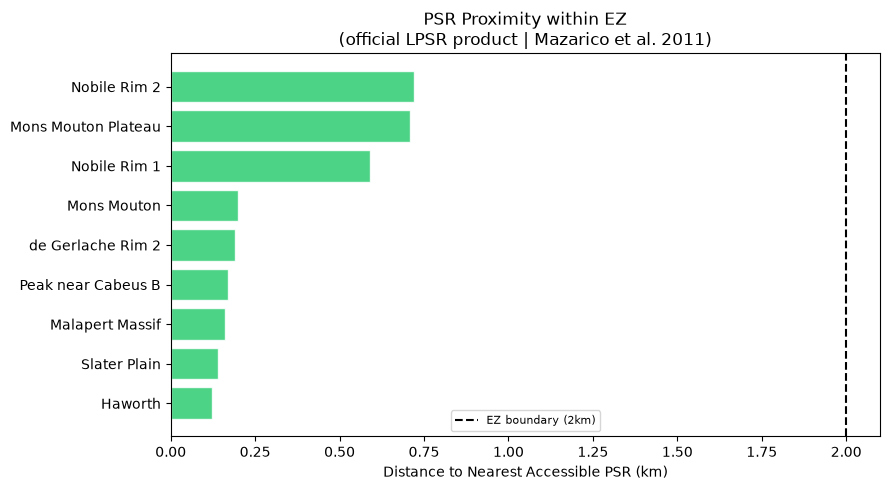

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

pv = lola_all.copy()
pv['PSR_dist_km_plot'] = pv['PSR_dist_km'].fillna(2.5)
pv = pv.sort_values('PSR_dist_km_plot')
colors_p = ['#2ecc71' if (r['Has_PSR_access'] and r['PSR_traverse_ok'])
            else '#e74c3c' for _, r in pv.iterrows()]

ax.barh(pv['Site'], pv['PSR_dist_km_plot'], color=colors_p,
        alpha=0.85, edgecolor='white')
ax.axvline(2.0, color='black', linestyle='--', lw=1.5, label='EZ boundary (2km)')
ax.set_xlabel('Distance to Nearest Accessible PSR (km)')
ax.set_title('PSR Proximity within EZ\n(official LPSR product | Mazarico et al. 2011)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

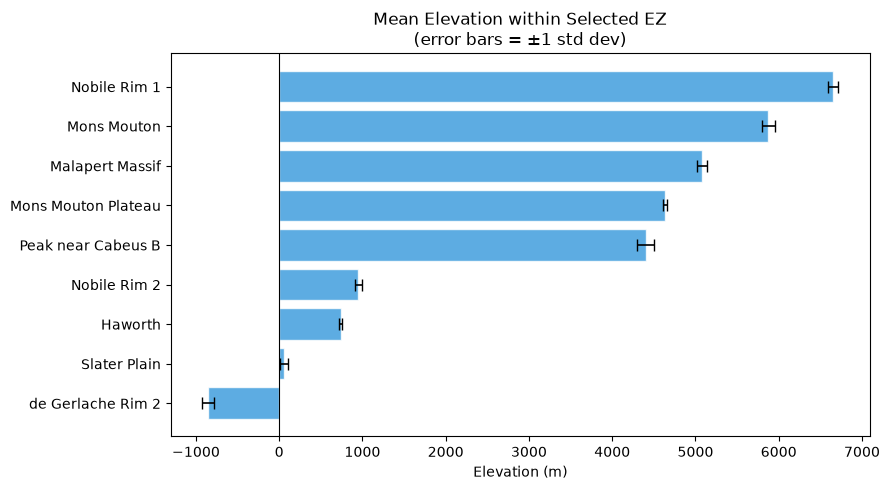

In [19]:
ev = lola_all.sort_values('Elevation_mean_m')

plt.figure(figsize=(9, 5))
plt.barh(ev['Site'], ev['Elevation_mean_m'],
         color='#3498db', alpha=0.8, edgecolor='white',
         xerr=ev['Elevation_std_m'],
         error_kw={'linewidth': 1.2, 'capsize': 4, 'color': '#2c3e50'})
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Elevation (m)')
plt.title('Mean Elevation within Selected EZ\n(error bars = ±1 std dev)')
plt.tight_layout()
plt.show()

In [20]:
lola_all.to_csv('../01_cleaned_data/lola_sites_summary.csv', index=False)

print(f"Total sites:               {len(lola_all)}")
print(f"Meets ALL 5 criteria:      {lola_all['Meets_all_criteria'].sum()}")
print(f"Partial (some unmet):      {(~lola_all['Meets_all_criteria']).sum()}")
print()
print("Sites with unmet criteria:")
for _, row in lola_all[~lola_all['Meets_all_criteria']].iterrows():
    print(f"  {row['Site']:25s} → {row['Unmet_criteria']}")

Total sites:               9
Meets ALL 5 criteria:      7
Partial (some unmet):      2

Sites with unmet criteria:
  Slater Plain              → DTE
  Peak near Cabeus B        → Slope
